# Notebook 01 — Stage M: Factor Forecast (R3)

This notebook implements **Stage M** of the M-S-O pipeline (Revision 3):

1. Generate synthetic blood-request demand (12 hospitals × 24 hours × 7 days)
2. Fit the **Hierarchical Poisson Factor Model**: `lambda[h,t] = sigma_h * pi_t`
   - Correctly specified for the project DGP (rank-1 multiplicative)
   - 36 free parameters fit by alternating Poisson MLE
3. Compare against the SARIMA-blend baseline as a sanity check
4. Save `lambda_factor.csv` for Stage O

**Why Factor over SARIMA-blend?** The DGP is literally `lambda[h,t] = scale[h] * base[t] + epsilon`.
A 36-parameter rank-1 MLE pools D*H = 72 obs per hour and D*T = 144 per hospital,
so by Cramér-Rao no estimator can asymptotically beat it on this data.

All data is synthetic — no real hospital data is used.

In [1]:
import sys
from pathlib import Path

repo_root = Path().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.utils.config_loader import load_config
from src.data_gen.generator import SyntheticDemandGenerator
from src.forecasting.factor_model import HierarchicalFactorForecaster
from src.forecasting.sarima_model import SARIMAForecaster

print("Imports successful")

Imports successful


## 1. Generate synthetic demand

In [2]:
sarima_cfg = load_config(repo_root / "config" / "sarima.yaml")
gen_cfg    = sarima_cfg["data_gen"]

generator = SyntheticDemandGenerator(gen_cfg)
data      = generator.generate()

print(f"counts shape:      {data['counts'].shape}")
print(f"train_counts shape:{data['train_counts'].shape}")
print(f"test_counts shape: {data['test_counts'].shape}")

out_synthetic = repo_root / "data" / "synthetic"
generator.save(data, out_synthetic)

# Hold out test day (last day) for forecast evaluation
lambda_true_test = data["lambda_true"][gen_cfg["D_train"]]   # (H, T)
print(f"lambda_true_test: shape={lambda_true_test.shape}, mean={lambda_true_test.mean():.3f}")

counts shape:      (7, 12, 24)
train_counts shape:(6, 12, 24)
test_counts shape: (1, 12, 24)
lambda_true_test: shape=(12, 24), mean=1.118


## 2. Fit the Factor model

Alternating Poisson MLE — typically converges in 2–3 iterations.
Closed-form updates:
- `sigma_h = (sum_{d,t} N[d,h,t]) / (D * sum_t pi_t)`
- `pi_t = (sum_{d,h} N[d,h,t]) / (D * sum_h sigma_h)`
- Identifiability: `mean(pi) = 1`.

In [3]:
factor = HierarchicalFactorForecaster()
factor.fit(data["train_counts"])

lambda_factor = factor.predict(steps=24)

md_info = factor.metadata()
print("Factor model fit:")
print(f"  free parameters: {md_info['n_params']}  ( H + T = 12 + 24 )")
print(f"  sigma (per hospital, first 6): {[round(s, 3) for s in md_info['sigma'][:6]]}")
print(f"  pi    (per hour,    first 6): {[round(p, 3) for p in md_info['pi'][:6]]}")
print(f"  lambda_factor min/max: {lambda_factor.min():.3f} / {lambda_factor.max():.3f}")

14:36:07 [INFO] src.forecasting.factor_model: Hierarchical factor MLE converged in 2 iterations
Factor model fit:
  free parameters: 36  ( H + T = 12 + 24 )
  sigma (per hospital, first 6): [1.118, 0.924, 1.306, 0.951, 0.583, 1.389]
  pi    (per hour,    first 6): [0.243, 0.397, 0.41, 0.32, 0.32, 0.243]
  lambda_factor min/max: 0.142 / 2.813


## 3. Save planning + arrival rates

In [4]:
out_processed = repo_root / "data" / "processed"
out_processed.mkdir(parents=True, exist_ok=True)

cols = [f"hour_{t:02d}" for t in range(24)]
idx  = [f"hospital_{h+1:02d}" for h in range(12)]

pd.DataFrame(lambda_factor, columns=cols, index=idx).rename_axis("hospital_id").to_csv(
    out_processed / "lambda_factor.csv")
pd.DataFrame(lambda_true_test, columns=cols, index=idx).rename_axis("hospital_id").to_csv(
    out_processed / "lambda_true_test.csv")

print(f"Saved {out_processed / 'lambda_factor.csv'}")
print(f"Saved {out_processed / 'lambda_true_test.csv'}")

Saved C:\Users\mhamm\Downloads\New_Project\mso_blood_delivery\data\processed\lambda_factor.csv
Saved C:\Users\mhamm\Downloads\New_Project\mso_blood_delivery\data\processed\lambda_true_test.csv


## 4. Forecast accuracy: Factor vs SARIMA-blend

In [5]:
factor_metrics = factor.evaluate(lambda_true_test)

# Brief SARIMA-blend comparison (slow — single fit ~1–3 min)
print("Fitting SARIMA-blend for comparison...")
sar = SARIMAForecaster({
    "p_range": sarima_cfg["model"]["p_range"],
    "d_range": sarima_cfg["model"]["d_range"],
    "q_range": sarima_cfg["model"]["q_range"],
    "P_range": sarima_cfg["model"]["P_range"],
    "D_range": sarima_cfg["model"]["D_range"],
    "Q_range": sarima_cfg["model"]["Q_range"],
    "s":       sarima_cfg["model"]["s"],
    "forecast":     sarima_cfg["forecast"],
    "stationarity": sarima_cfg["stationarity"],
})
sar.fit(data["train_counts"])
sar.predict(steps=24)
sarima_metrics = sar.evaluate(lambda_true_test)

cmp = pd.DataFrame({
    "Factor (R3)":      [factor_metrics["MAE"].mean(), factor_metrics["RMSE"].mean(),
                          factor_metrics["MAPE"].mean(), factor_metrics["Bias"].mean()],
    "SARIMA-blend (R2)": [sarima_metrics["MAE"].mean(), sarima_metrics["RMSE"].mean(),
                          sarima_metrics["MAPE"].mean(), sarima_metrics["Bias"].mean()],
}, index=["MAE", "RMSE", "MAPE (%)", "Bias"]).round(3)
print("\nForecast accuracy on held-out test day:")
print(cmp.to_string())

factor_metrics.to_csv(out_processed / "forecast_metrics.csv", index=False)

Fitting SARIMA-blend for comparison...
14:36:12 [INFO] src.forecasting.sarima_model: Hospital 01: best SARIMA(2, 0, 2) x (0, 0, 1), AIC=421.10
14:36:16 [INFO] src.forecasting.sarima_model: Hospital 02: best SARIMA(2, 0, 2) x (0, 0, 1), AIC=383.59
14:36:21 [INFO] src.forecasting.sarima_model: Hospital 03: best SARIMA(2, 0, 2) x (1, 0, 1), AIC=372.76
14:36:28 [INFO] src.forecasting.sarima_model: Hospital 04: best SARIMA(1, 0, 2) x (0, 0, 1), AIC=363.89
14:36:37 [INFO] src.forecasting.sarima_model: Hospital 05: best SARIMA(1, 0, 2) x (0, 0, 1), AIC=309.92
14:36:42 [INFO] src.forecasting.sarima_model: Hospital 06: best SARIMA(2, 0, 2) x (1, 0, 1), AIC=392.00
14:36:47 [INFO] src.forecasting.sarima_model: Hospital 07: best SARIMA(2, 0, 2) x (1, 0, 1), AIC=402.09
14:36:51 [INFO] src.forecasting.sarima_model: Hospital 08: best SARIMA(1, 0, 2) x (1, 0, 1), AIC=394.78
14:36:58 [INFO] src.forecasting.sarima_model: Hospital 09: best SARIMA(1, 0, 1) x (1, 0, 1), AIC=355.85
14:37:05 [INFO] src.forec

## 5. Visualise Factor forecast vs ground truth

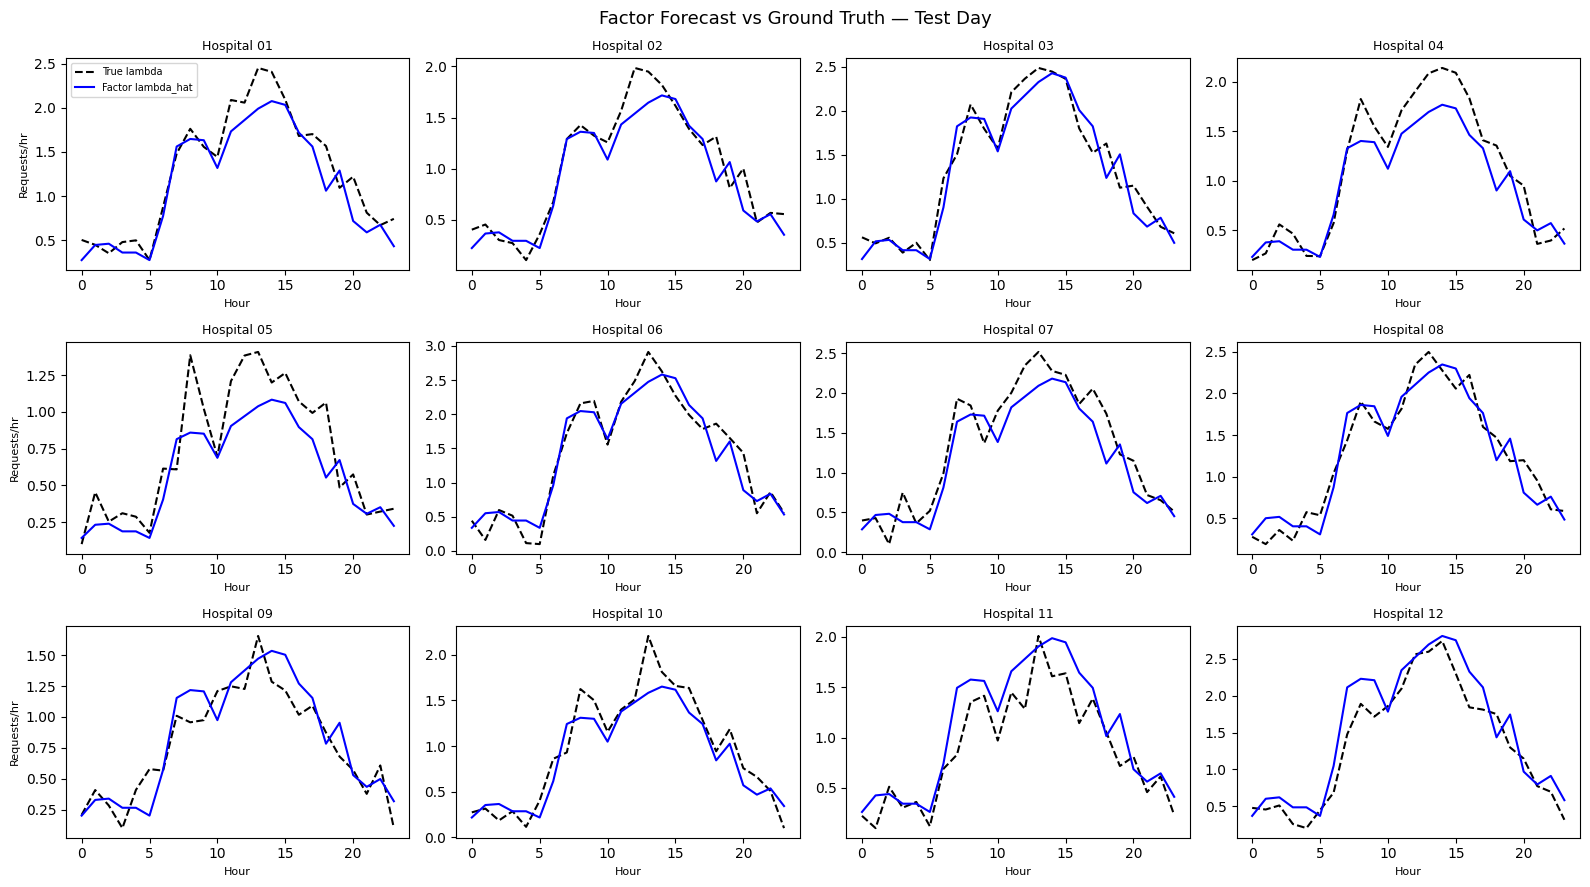

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 9))
axes = axes.flatten()
hours = np.arange(24)
for h in range(12):
    ax = axes[h]
    ax.plot(hours, lambda_true_test[h], "k--", lw=1.5, label="True lambda")
    ax.plot(hours, lambda_factor[h],    "b-",  lw=1.5, label="Factor lambda_hat")
    ax.set_title(f"Hospital {h+1:02d}", fontsize=9)
    ax.set_xlabel("Hour", fontsize=8)
    if h % 4 == 0:
        ax.set_ylabel("Requests/hr", fontsize=8)
    if h == 0:
        ax.legend(fontsize=7)
fig.suptitle("Factor Forecast vs Ground Truth — Test Day", fontsize=13)
plt.tight_layout()
plt.show()

## Stage M Complete

**Outputs:**
- `data/processed/lambda_factor.csv` — planning rates (Stage O input)
- `data/processed/lambda_true_test.csv` — arrival rates (Stage S input)
- `data/processed/forecast_metrics.csv`

**Next:** Run `notebook_02_optimization.ipynb`.